Example notebook `python/Notebooks/snippets/graphics.ipynb`: the types of `GraphicsData` in one model, as
dictionaries and with the functions of `exudyn.graphics`, and the model drawn with the raytracer and its materials.

In [1]:
import exudyn as exu
from exudyn.utilities import *   #includes itemInterface, the Create functions
import exudyn.graphics as graphics
from exudyn.interactive import ShowImage
import numpy as np

SC = exu.SystemContainer()
mbs = SC.AddSystem()

**Line**: a polygonal line through the points, here as a dictionary - a red square with side length 1 -, drawn by a
ground:

In [2]:
graphicsData = {'type':'Line',
                'color': [1,0,0,1], #red
                'data': [[0,0,0],
                         [1,0,0],
                         [1,1,0],
                         [0,1,0],
                         [0,0,0]]}

vGround = VObjectGround(graphicsData=[graphicsData])
oGround = mbs.AddObject(ObjectGround(referencePosition=[0,0,0],
                                     visualization=vGround))

The same, much shorter, with `graphics.Lines`:

In [3]:
gSquare = graphics.Lines([[0,0,0],[1,0,0],[1,1,0],[0,1,0],[0,0,0]],
                         color=graphics.color.red)

**Lines**: separate lines, straight with two points each or quadratic (curved) with three - the end points, then the
mid point:

In [4]:
gLShape = {'type':'Lines',
           'points': [[0,-0.3,0], [1,-0.3,0],  [1,-0.3,0], [1,-1.3,0]], #two lines: an L-shape with side length 1
           'colors': [[0,0,1,1]]*4}                          #blue
gArc = {'type':'Lines', 'shape':'quadratic',                 #a quarter circle, approximately
        'points': [[1,0,0], [0,1,0], [0.7071,0.7071,0]],     #end points, then the mid point
        'colors': [[1,0,0,1]]*3}

**Circle** and **Text**:

In [5]:
gCircle = {'type':'Circle',
           'color': [0,0,1,1],  #blue
           'radius': 0.5,
           'position':[0.5,0.5,0]}
gText = graphics.Text(point=[0,1.2,0], text='GraphicsData', color=graphics.color.black)

**Spheres**: many spheres in one item, with a radius and a color each:

In [6]:
gSpheres = graphics.Spheres(points=[[1.5,0,0],[1.5,0.5,0]], radii=[0.1,0.2],
                            colors=[graphics.color.red, graphics.color.green])

**TriangleList**: points and triangles - here a tetrahedron, its triangles counter-clockwise seen from outside -, and
what most functions of `exudyn.graphics` return, such as a brick with its edges:

In [7]:
gTetrahedron = graphics.FromPointsAndTrigs(points=[[2,0,0],[2.6,0,0],[2,0.6,0],[2,0,0.6]],
                                           triangles=[[0,2,1],[0,1,3],[0,3,2],[1,2,3]],
                                           color=graphics.color.orange)
gBrick = graphics.Brick(centerPoint=[2.3,1,0.15], size=[0.6,0.4,0.3], color=graphics.color.steelblue,
                        addEdges=True)

**Raytracing**: a material instead of the alpha value of a color - a chrome sphere - is what the raytracer shows
with reflections; the OpenGL renderer draws it in its color:

In [8]:
gSphere = graphics.Sphere(point=[0.5,0.5,0.4], radius=0.3,
                          color=graphics.color.dodgerblue[0:3]+[graphics.material.indexChrome],
                          nTiles=32)

All of them on a second ground, on a checkerboard, and the model drawn with the raytracer:

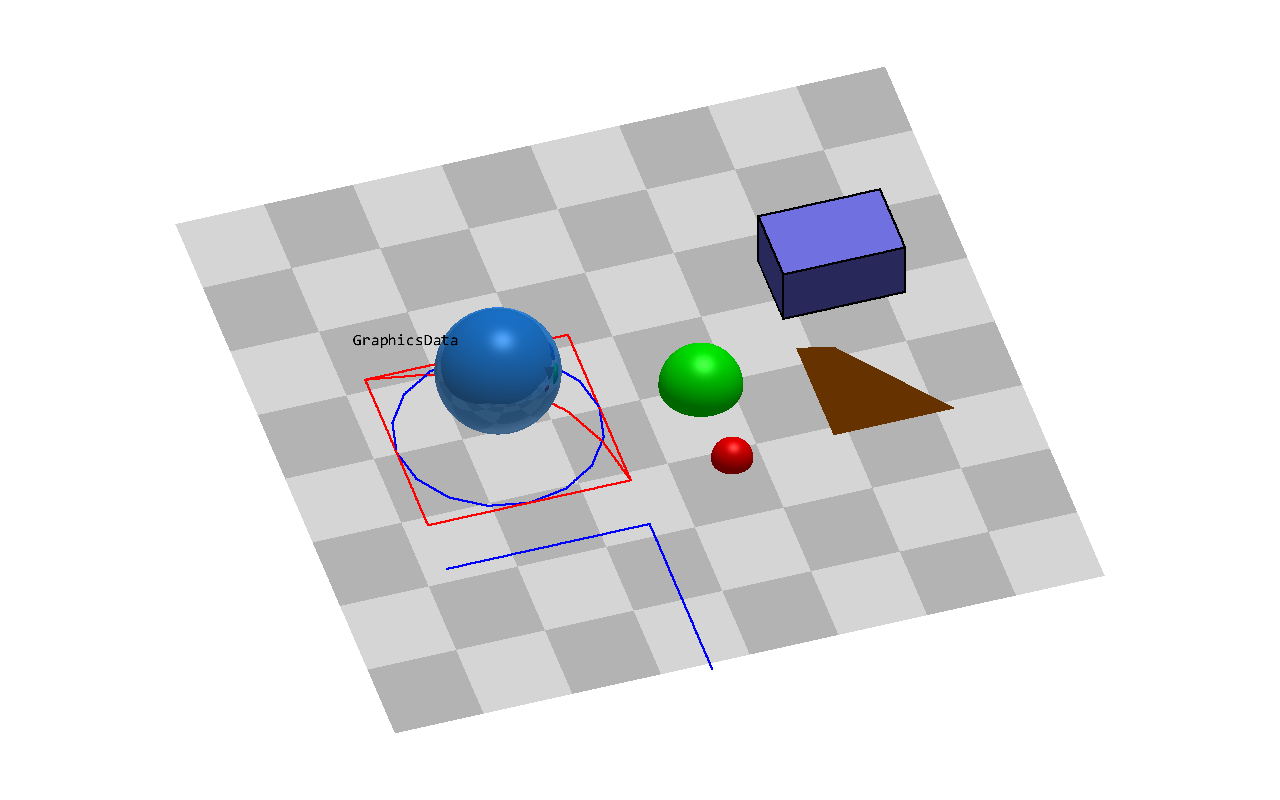

In [9]:
gFloor = graphics.CheckerBoard(point=[1.2,0.5,-0.01], size=3.5, nTiles=8)
mbs.CreateGround(graphicsDataList=[gFloor, gSquare, gLShape, gArc, gCircle, gText, gSpheres,
                                   gTetrahedron, gBrick, gSphere])
mbs.Assemble()

SC.visualizationSettings.openGL.multiSampling = 1
SC.visualizationSettings.openGL.light1.enable = False
SC.visualizationSettings.raytracer.numberOfThreads = 8 #adjust to your number of threads
SC.visualizationSettings.openGL.lineWidth = 3
SC.visualizationSettings.general.showSolverInformation = False
SC.visualizationSettings.view0.window.showComputationInfo = False
SC.visualizationSettings.view0.scene.drawCoordinateSystem = False
view = RotationMatrixZ(-0.3) @ RotationMatrixX(0.5*np.pi-0.8) #the view from the front and above, z up
image = ShowImage(SC, size=[1280,800], modelRotation=view)

In a script, `SC.visualizationSettings.view0.camera.useRaytracer = True` before `mbs.SolutionViewer()` (or
`SC.renderer.Start()`) draws the render window with the raytracer; start with a small window, or with
`raytracer.imageSizeFactor = 3`, which reduces the resolution.